# Análisis Exploratorio de Datos (EDA)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

# Cargar el Dataset
df = pd.read_csv('../data/retailmax.csv')

## 1. Limpieza de Datos

In [2]:
# Revisión general: dimensiones, tipos de dato y presencia de valores nulos
print("Dimensiones (filas, columnas):", df.shape)
print()
print("Tipos de dato por columna:")
print(df.dtypes)
print()
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Filas duplicadas:", df.duplicated().sum())
print()

# Revisión de rangos válidos según el diccionario de datos esperado
# (Age > 0, Annual Income > 0, Spending Score entre 1 y 100)
rangos_invalidos = df[
    (df['Age'] <= 0) |
    (df['Annual Income (k$)'] <= 0) |
    (~df['Spending Score (1-100)'].between(1, 100))
]
print("Filas con valores fuera de rango esperado:", len(rangos_invalidos))

# Categorías únicas en variables categóricas (para detectar inconsistencias de escritura,
# ej. 'Male' vs 'male' vs 'M')
print()
print("Categorías únicas en 'Gender':", df['Gender'].unique())

Dimensiones (filas, columnas): (200, 5)

Tipos de dato por columna:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Valores nulos por columna:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Filas duplicadas: 0

Filas con valores fuera de rango esperado: 0

Categorías únicas en 'Gender': <StringArray>
['Male', 'Female']
Length: 2, dtype: str


**Resultado de la limpieza:** el dataset no presenta valores nulos, duplicados ni valores fuera de rango, "
y la variable categórica `Gender` solo tiene dos categorías bien escritas (`Male`, `Female`). No fue necesario "
imputar, eliminar filas ni corregir inconsistencias.

*¿Por qué revisar esto igual si "ya se ve limpio"?* Nunca se debe asumir que un dataset está limpio sin comprobarlo: "
nulos silenciosos, duplicados o categorías mal escritas (`'Male'` vs `'male '`) son errores comunes que, si no se "
detectan aquí, se propagan al modelo y distorsionan las distancias que usa K-means para formar los clusters.

## 2. Normalización de las Columnas

In [3]:
# Normalizamos los NOMBRES de las columnas: minúsculas, snake_case y sin unidades/espacios.
# Esto es una buena práctica de higiene de datos (facilita el código: df.annual_income en vez de
# df['Annual Income (k$)']) y NO debe confundirse con "normalizar" en el sentido estadístico
# (reescalar los valores numéricos).
df = df.rename(columns={
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income_k',
    'Spending Score (1-100)': 'spending_score'
})

# Ajustamos el tipo de 'gender' a category: usa menos memoria y deja explícito que es
# una variable categórica y no texto libre.
df['gender'] = df['gender'].astype('category')

df.head()

,customer_id,gender,age,annual_income_k,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Nota importante — por qué NO escalamos los valores numéricos todavía:**

- *Ventaja de hacerlo ahora:* sería más rápido y los histogramas ya quedarían en una escala común.
- *Desventaja / por qué está mal hacerlo aquí:* si ajustamos un `StandardScaler` o `MinMaxScaler` con **todo** el dataset en la etapa de EDA, esos parámetros (media, desviación estándar, mínimo, máximo) se calculan usando información que en un escenario real todavía no existe (por ejemplo, datos de clientes nuevos). Eso es una forma de **data leakage**: el modelo "espía" estadísticas de datos que en producción no debería conocer de antemano.

**Alternativa correcta:** el escalado (`StandardScaler`, ya que K-means usa distancia euclidiana y las variables tienen escalas distintas: la edad va de ~18 a 70, mientras que el ingreso va de ~15 a 137) se ajustará **más adelante, dentro del pipeline del modelo**, y si se separan datos de entrenamiento/prueba, el escalador se ajusta únicamente con el conjunto de entrenamiento.

# 1. ¿Cuál es la distribución de edades de los clientes?

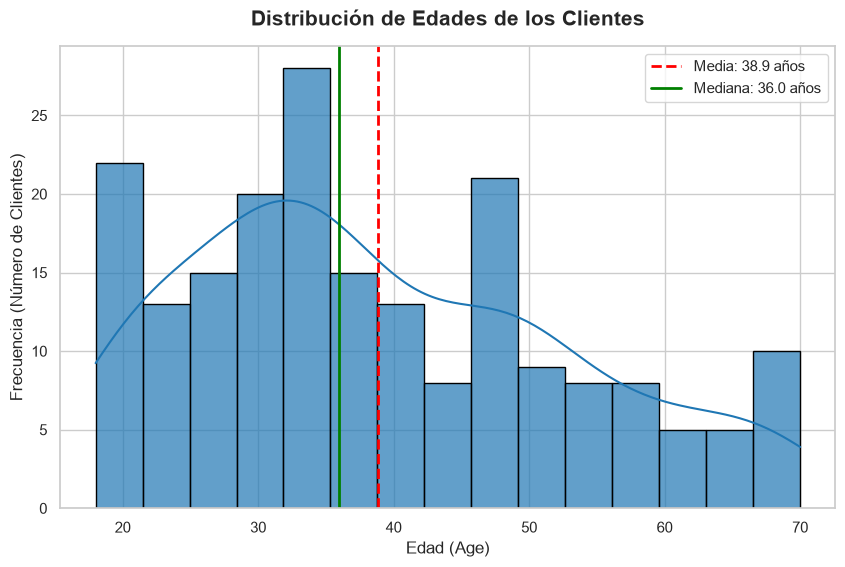

In [4]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=15, kde=True, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.title('Distribución de Edades de los Clientes', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)
plt.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["age"].mean():.1f} años')
plt.axvline(df['age'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df["age"].median():.1f} años')
plt.legend(fontsize=11)
plt.show()

# 2. ¿Existen diferencias en los ingresos anuales entre hombres y mujeres?

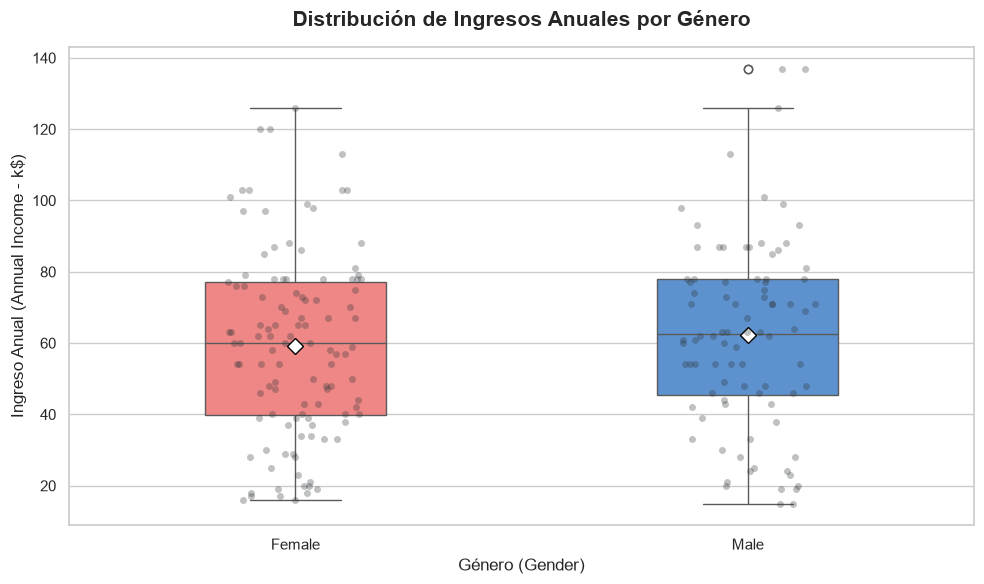

In [5]:
plt.figure(figsize=(10, 6))

# Gráfico de caja (boxplot) con strip plot superpuesto para ver la distribución individual
sns.boxplot(
    data=df, 
    x='gender', 
    y='annual_income_k', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    width=0.4,
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Mostrar los puntos individuales de datos de manera sutil
sns.stripplot(
    data=df, 
    x='gender', 
    y='annual_income_k', 
    color='#2d3436', 
    alpha=0.3, 
    jitter=0.15, 
    size=5
)

plt.title('Distribución de Ingresos Anuales por Género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género (Gender)', fontsize=12)
plt.ylabel('Ingreso Anual (Annual Income - k$)', fontsize=12)

plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de ingresos anuales entre hombres y mujeres, observamos que **no existen diferencias drásticas**, aunque sí se aprecian ligeras variaciones a favor del grupo masculino:

1. **Promedio (Media) y Mediana:**
   - Los **hombres** tienen un ingreso anual promedio de **62.23 k$** y una mediana de **62.50 k$**.
   - Las **mujeres** tienen un ingreso anual promedio de **59.25 k$** y una mediana de **60.00 k$**.
   - Esto representa una ligera diferencia de **~2.98 k$ en la media** y **2.50 k$ en la mediana** a favor de los hombres.

2. **Dispersión y Límites:**
   - La dispersión (desviación estándar) es sumamente similar en ambos grupos: **26.64 k$** para hombres y **26.01 k$** para mujeres.
   - Los rangos intercuartílicos y las cajas en el gráfico muestran que el 50% central de la población se encuentra en rangos muy similares, aunque el límite inferior del 25% de los hombres (45.5 k$) es ligeramente mayor al de las mujeres (39.75 k$).
   - El ingreso máximo registrado pertenece a un hombre con **137 k$**, mientras que el de las mujeres es de **126 k$**.

**Conclusión:** Aunque estadísticamente los hombres muestran ingresos ligeramente superiores en términos de medidas de tendencia central (media y mediana) y valores máximos, las distribuciones se superponen en gran medida. Esto sugiere que **el género no es un factor determinante o altamente diferenciador** para el nivel de ingresos en este conjunto de datos.

# 3. ¿Cómo se distribuye la puntuación de gastos entre los diferentes rangos de edades?

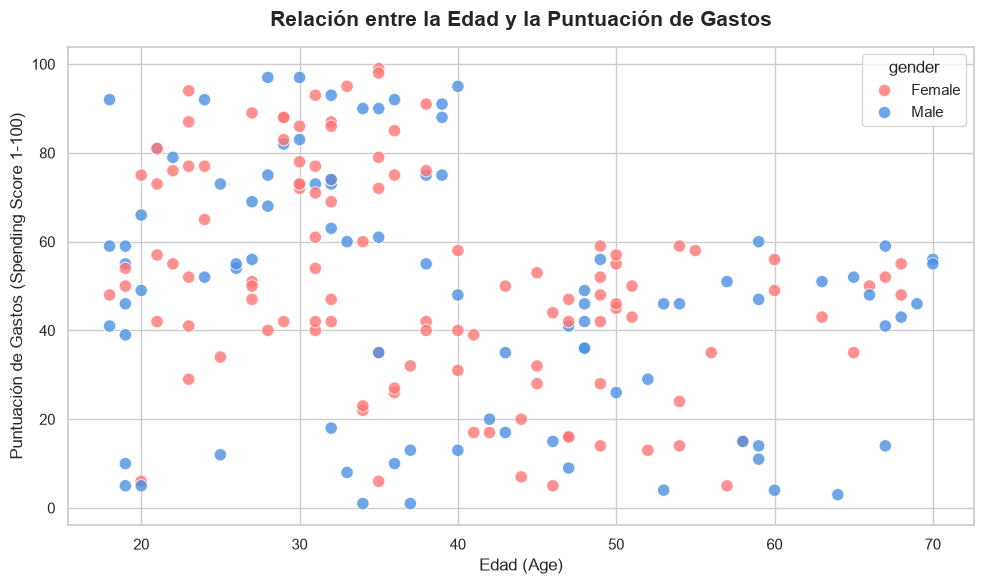

In [6]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='age',
    y='spending_score',
    hue='gender',
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    alpha=0.8,
    s=80
)

plt.title('Relación entre la Edad y la Puntuación de Gastos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Puntuación de Gastos (Spending Score 1-100)', fontsize=12)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de la puntuación de gastos (`Spending Score (1-100)`) en función de la edad (`Age`), podemos extraer conclusiones muy claras y valiosas sobre el comportamiento de los clientes:

1. **Límite de Edad para Altos Consumidores:**
   - Se observa una clara barrera alrededor de los **40 años**. Prácticamente **ningún cliente mayor de 40 años supera una puntuación de gasto de 60**.
   - La gran mayoría de los clientes de más de 40 años se concentra en un rango de puntuación moderado y bajo (entre 1 y 60 puntos), con una media que ronda los **32-34 puntos**.

2. **Comportamiento en Clientes Jóvenes (< 40 años):**
   - Los clientes de entre 18 y 40 años muestran una dispersión mucho mayor y son los únicos que alcanzan puntuaciones de gastos sobresalientes (entre 60 y 100 puntos).
   - En este segmento joven, se aprecian claramente dos grupos bien diferenciados: uno de perfil muy ahorrador/moderado (puntuaciones bajas) y otro de perfil altamente consumidor (puntuaciones que van de 60 a 99 puntos).

**Conclusión:** La edad es un factor altamente segmentador en este conjunto de datos. Mientras que los clientes jóvenes (< 40 años) presentan un grupo con potencial de compra sumamente elevado, el segmento de mayor edad (>= 40 años) exhibe un comportamiento de gasto mucho más moderado y homogéneo, sin superar nunca la franja alta de puntuación.

# 4. ¿Cómo se distribuyen los ingresos anuales de los clientes?

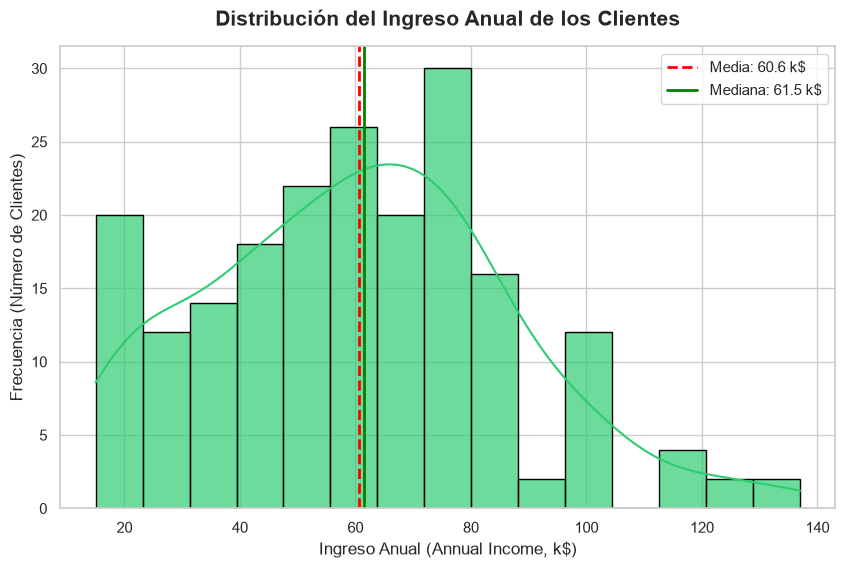

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['annual_income_k'], bins=15, kde=True, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribución del Ingreso Anual de los Clientes', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Ingreso Anual (Annual Income, k$)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)
plt.axvline(df['annual_income_k'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["annual_income_k"].mean():.1f} k$')
plt.axvline(df['annual_income_k'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df["annual_income_k"].median():.1f} k$')
plt.legend(fontsize=11)
plt.show()

### **Análisis de los Resultados**

**Insight:** la distribución del ingreso anual es aproximadamente simétrica y unimodal, concentrada entre 40 y 80 k$, con media (60.6 k$) y mediana (61.5 k$) muy cercanas entre sí. No hay una cola larga marcada ni valores extremos evidentes.

**Por qué es útil / qué hipótesis plantea:** al no tener sesgo fuerte ni outliers extremos, el ingreso anual es un buen candidato como feature para K-means sin necesidad de transformaciones adicionales (como log-transform), solo requerirá el escalado estándar junto con las demás variables. Esto abre la hipótesis de que los grupos de clientes no se van a formar únicamente por "cuánto ganan", sino por la **combinación** de cuánto ganan y cuánto gastan (ver insight 6).

# 5. ¿Cómo se distribuye la puntuación de gastos (Spending Score)?

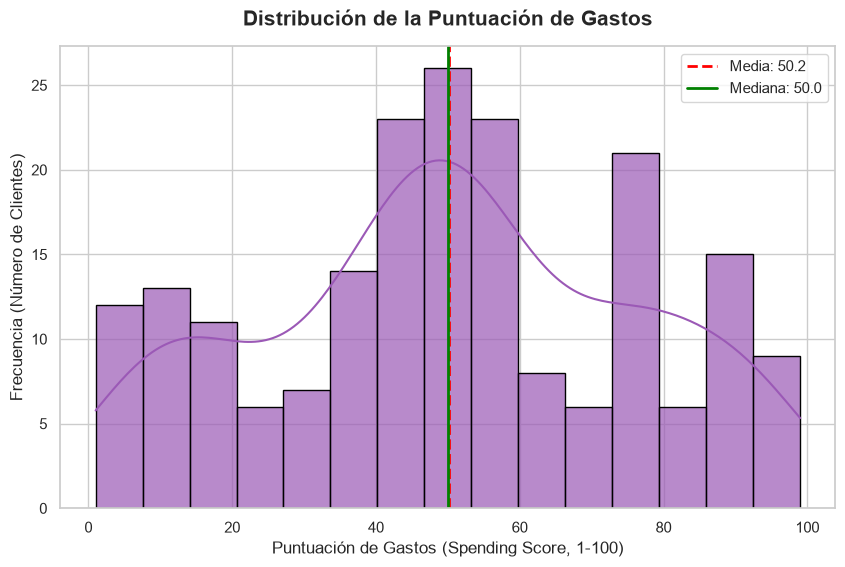

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['spending_score'], bins=15, kde=True, color='#9b59b6', edgecolor='black', alpha=0.7)
plt.title('Distribución de la Puntuación de Gastos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Puntuación de Gastos (Spending Score, 1-100)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)
plt.axvline(df['spending_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["spending_score"].mean():.1f}')
plt.axvline(df['spending_score'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df["spending_score"].median():.1f}')
plt.legend(fontsize=11)
plt.show()

### **Análisis de los Resultados**

**Insight:** a diferencia del ingreso, el spending score muestra una distribución más plana, con dos concentraciones leves cerca de los extremos (alrededor de 15-20 y de 75-80), además del pico central esperado alrededor de 50.

**Por qué es útil / qué hipótesis plantea:** esta forma "achatada" con acumulaciones en los extremos sugiere que, por sí sola, esta variable ya insinúa la existencia de subgrupos de comportamiento (clientes de gasto muy bajo, medio y muy alto) en lugar de un único comportamiento "promedio". Es una señal temprana de que **el clustering va a encontrar estructura real** en los datos y no solo ruido, lo cual justifica el uso de K-means más adelante.

# 6. ¿Existe una relación entre el ingreso anual y la puntuación de gastos?

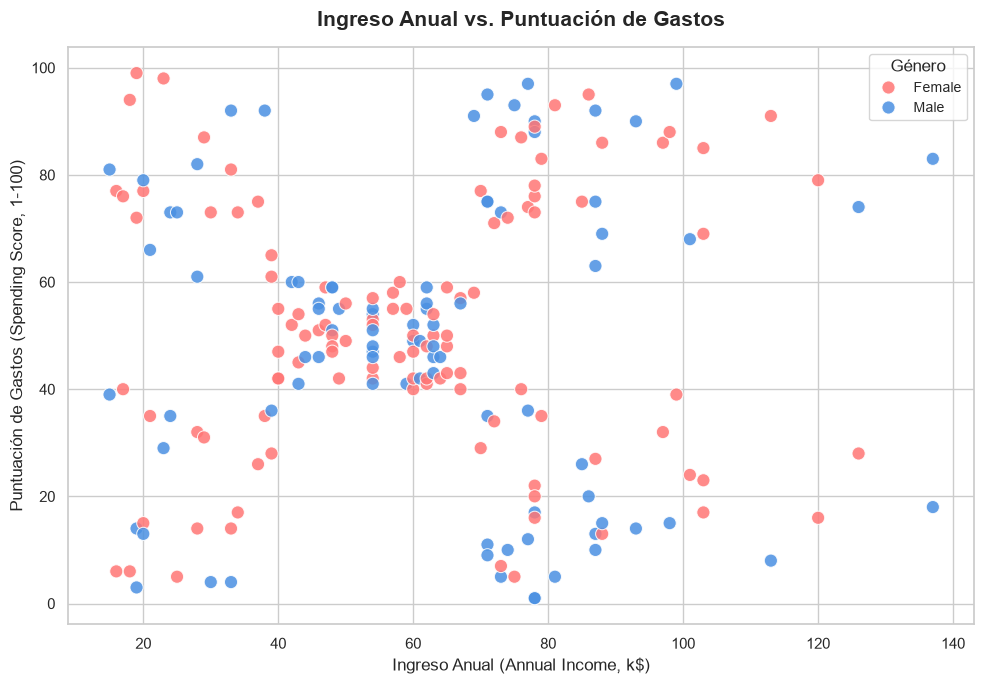

In [9]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='annual_income_k',
    y='spending_score',
    hue='gender',
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    alpha=0.85,
    s=90
)
plt.title('Ingreso Anual vs. Puntuación de Gastos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Ingreso Anual (Annual Income, k$)', fontsize=12)
plt.ylabel('Puntuación de Gastos (Spending Score, 1-100)', fontsize=12)
plt.legend(title='Género', fontsize=10)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

**Insight:** este es el gráfico más revelador del EDA. Al cruzar ingreso anual con puntuación de gastos aparecen **cinco agrupaciones visualmente separables**: (1) ingreso bajo y gasto bajo, (2) ingreso bajo y gasto alto (compradores impulsivos), (3) ingreso medio y gasto medio (el grupo mayoritario y más "promedio"), (4) ingreso alto y gasto bajo (ahorradores), y (5) ingreso alto y gasto alto (clientes premium). El género no parece separar estos grupos (los colores están mezclados dentro de cada agrupación).

**Por qué es útil / qué hipótesis plantea:** esta es la evidencia visual directa de que **existe una estructura de clusters "natural"** en los datos, y sugiere fuertemente que `annual_income_k` y `spending_score` son las dos variables con mayor poder de segmentación del dataset — de hecho, son el par de features clásico para entrenar K-means en este tipo de problema. También plantea la hipótesis de que **k = 5** podría ser un buen número de clusters a validar más adelante con el método del codo (elbow method) y el coeficiente de silueta.

# 7. ¿Cómo se correlacionan entre sí las variables numéricas?

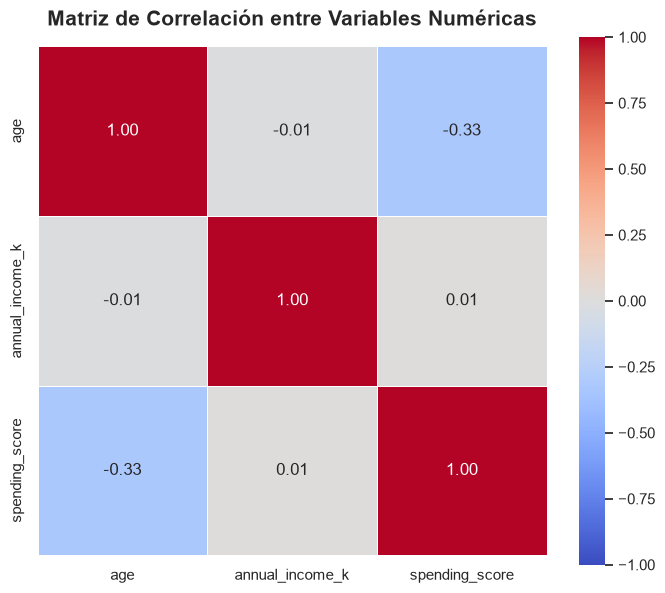

In [10]:
plt.figure(figsize=(7, 6))
corr = df[['age', 'annual_income_k', 'spending_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

**Insight:** las correlaciones lineales (Pearson) entre `age`, `annual_income_k` y `spending_score` son débiles en todos los casos (la más fuerte es una correlación negativa moderada-baja entre `age` y `spending_score`, consistente con el insight 3). `annual_income_k` y `spending_score` prácticamente no están correlacionadas de forma lineal.

**Por qué es útil / qué hipótesis plantea:** que dos variables tengan baja correlación lineal es en realidad **bueno para K-means**: significa que cada una aporta información distinta (no redundante), lo cual ayuda a que el algoritmo forme clusters más ricos en vez de duplicar la misma señal en dos ejes. Ojo: esto NO contradice el insight 6 — ahí la relación entre income y spending score no es lineal sino de agrupamiento (varios grupos en distintas zonas del plano), algo que la correlación de Pearson no puede capturar porque solo mide relación lineal.

# 8. ¿Cuál es la proporción de clientes por género?

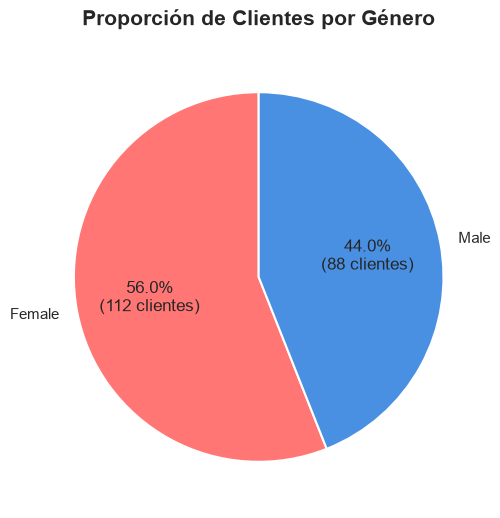

In [11]:
plt.figure(figsize=(7, 6))
conteo = df['gender'].value_counts()
colores = ['#ff7675' if g == 'Female' else '#4a90e2' for g in conteo.index]
plt.pie(
    conteo,
    labels=conteo.index,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p * len(df) / 100))} clientes)',
    colors=colores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Proporción de Clientes por Género', fontsize=15, fontweight='bold', pad=15)
plt.show()

### **Análisis de los Resultados**

**Insight:** el dataset está moderadamente desbalanceado hacia el género femenino (56%, 112 clientes) frente al masculino (44%, 88 clientes), aunque no es un desbalance extremo.

**Por qué es útil / qué hipótesis plantea:** confirma que ninguno de los dos grupos es tan pequeño como para generar problemas estadísticos de representatividad si se quisiera analizar por separado. Combinado con los insights 2 y 6 (donde el género no mostró diferencias relevantes en ingreso ni en los grupos de gasto), se plantea la hipótesis de que **`gender` no aporta valor discriminante para el clustering** y es razonable dejarlo fuera de las features del modelo K-means, usándolo únicamente como variable descriptiva para caracterizar los clusters después de formados.